In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm

In [3]:
df = pd.read_csv("../data/coffee_ratings_clean.csv").dropna()
df.isnull().sum()

country_of_origin       0
variety                 0
processing_method       0
total_cup_points        0
aroma                   0
flavor                  0
acidity                 0
body                    0
balance                 0
altitude_mean_meters    0
dtype: int64

In [15]:
print("Exploring 4 Research Questions:\n")
print("1. Which coutries produce the highest-rated coffee?\n")
print("2. How does coffee processing method relate to overall coffee rating?\n")
print("3. Is growing altitude associated with coffee quality?\n")
print("4. Which tasting characteristics are most strongly assocociated with overall coffee quality?\n")

Exploring 4 Research Questions:

1. Which coutnies produce the highest-rateed coffee?

2. How does coffee processing method relate to overall coffee rating?

3. Is growing altitude associated with coffee quality?

4. Which tasting characteristics are most strongly assocociated with overall coffee quality?



Reseach Question 1: With at least 10 reviews, which coutnies produce the highest-rated coffee?



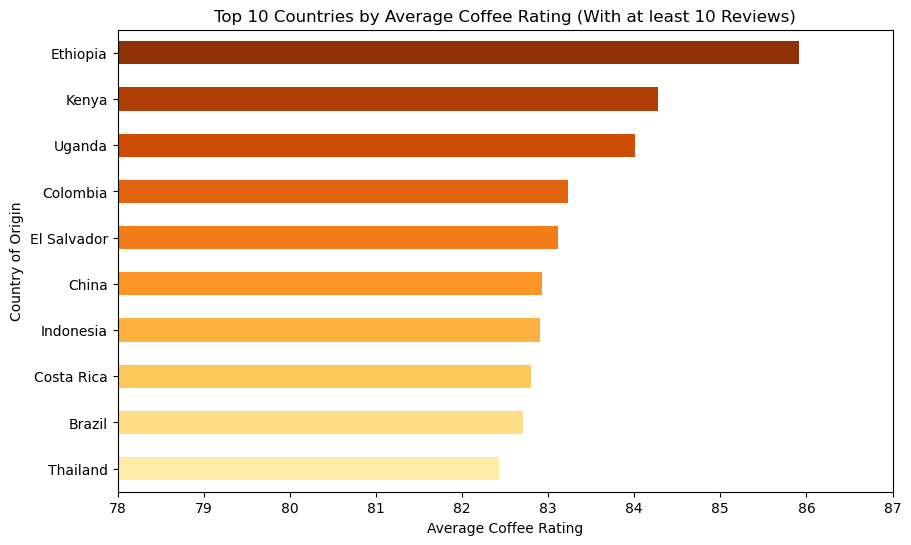

In [14]:
print("Reseach Question 1: With at least 10 reviews, which coutnies produce the highest-rated coffee?\n")

countriesByRating = (
    df.groupby("country_of_origin")["total_cup_points"]
    .agg(["mean", "count"])
)

countriesByRating = (
    countriesByRating[countriesByRating["count"] >= 10]
    .sort_values(by = "mean", ascending = False)
    .head(10)
)


colors = mpl.colormaps["YlOrBr"](range(50, 256, 20))

top10 = countriesByRating["mean"].sort_values().plot(
    kind = "barh",
    figsize = (10, 6),
    color = colors,
    title = "Top 10 Countries by Average Coffee Rating (With at least 10 Reviews)",
    ylabel = "Country of Origin",
    xlabel = "Average Coffee Rating"
)

plt.xlim(78, 87)
plt.show()

Among countries with at least 10 reviews, Ethiopia has the highest coffee rating at around 86 points, followed by Kenya and Uganda. However, the top 10 countries were relatively close in average rating, ranging from about 82.5 to 86 points. This sugguests that while some countires had higher average ratings, the difference in coffee scores were relatively small. 

In [19]:
df_altitude = df[['altitude_mean_meters', 'total_cup_points']].dropna()

# X = altitude , Y = coffee rating
X = df_altitude['altitude_mean_meters']
y = df_altitude['total_cup_points']

X = sm.add_constant(X)  # Add a constant term for the intercept

#fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       total_cup_points   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     49.16
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           4.17e-12
Time:                        16:26:03   Log-Likelihood:                -2494.4
No. Observations:                1068   AIC:                             4993.
Df Residuals:                    1066   BIC:                             5003.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   80.5612 

Altitude was statistically significant predictor of coffee rating (p < 0.000>). However, the R^2 value was only 0.044 meaning  altitude explains about 4.4% of the variation in coffee ratings. This suggests that while altitude is a related to coffee ratings, it is a relatively weak predictor, and other facctors likely have a greater influence on coffee quality. 

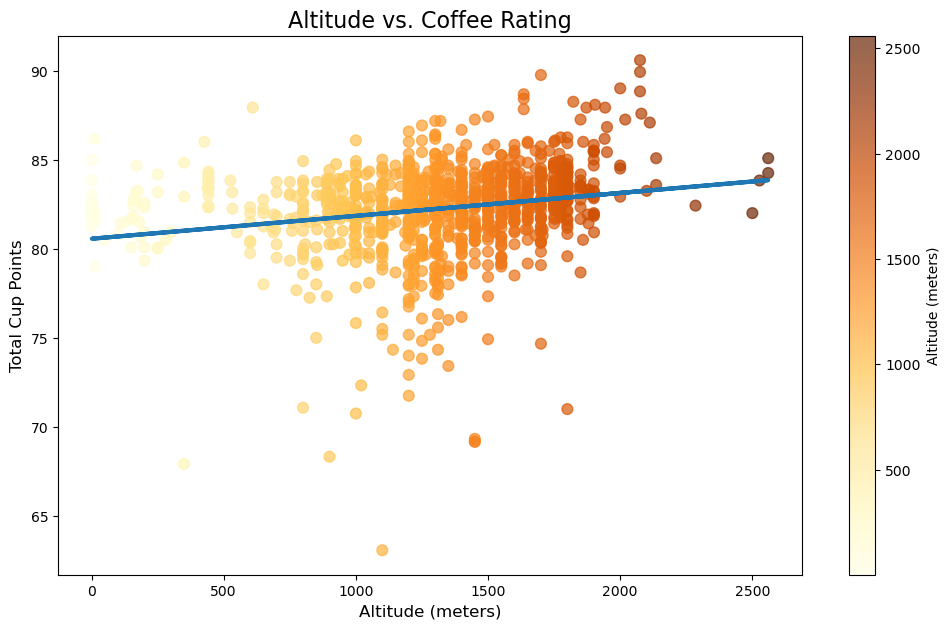

In [26]:
plt.figure(figsize=(12, 7))  

plt.scatter(
    df_altitude["altitude_mean_meters"],
    df_altitude["total_cup_points"],
    c=df_altitude["altitude_mean_meters"],
    cmap="YlOrBr",
    alpha=0.7,
    s=60
)

#regression ine 
x = df_altitude["altitude_mean_meters"]
y = df_altitude["total_cup_points"]

m, b = np.polyfit(x, y, 1)

plt.plot(
    x, 
    m*x + b, 
    linewidth=3,
)

plt.colorbar(label="Altitude (meters)")

plt.xlabel("Altitude (meters)", fontsize=12)
plt.ylabel("Total Cup Points", fontsize=12)
plt.title("Altitude vs. Coffee Rating", fontsize = 16)

plt.show()